In [913]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [914]:
df = pd.read_csv("../data/서울교통공사_지하철혼잡도정보_20240930.csv",encoding="EUC-KR")
df2 = pd.read_csv("../data/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv",encoding="EUC-KR")

In [915]:
df2

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202411,1호선,동대문,590,18,11507,1945,9996,6511,16584,...,9536,869,2870,2,219,0,0,0,0,20241203
1,202411,1호선,동묘앞,180,1,2890,959,3755,5025,9119,...,4506,137,2065,1,272,0,0,0,0,20241203
2,202411,1호선,서울역,619,19,8411,8848,13670,58234,42622,...,14302,3414,3953,0,187,0,0,0,0,20241203
3,202411,1호선,시청,71,0,2029,5239,3818,27038,7955,...,3948,575,1036,2,17,0,0,0,0,20241203
4,202411,1호선,신설동,385,21,9307,2313,10188,9168,22551,...,9065,426,2683,1,7,0,0,0,0,20241203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70547,201501,중앙선,운길산,0,0,177,56,642,403,1292,...,633,3,222,0,0,0,0,0,0,20151223
70548,201501,중앙선,원덕,1,0,292,4,415,46,537,...,383,3,157,0,0,0,0,0,0,20151223
70549,201501,중앙선,중랑,14,1,4929,424,8539,2084,22160,...,6501,86,1617,0,0,0,0,0,0,20151223
70550,201501,중앙선,팔당,0,0,161,50,368,149,1227,...,336,8,85,0,0,0,0,0,0,20151223


In [916]:
md = df[df["출발역"] == "명동"]

In [917]:
df

,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,7시30분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,평일,1,158,청량리,상선,9.7,8.7,5.0,8.7,10.3,...,26.1,25.7,27.8,23.8,22.4,23.7,22.9,15.1,8.7,0.0
1,평일,1,158,청량리,하선,21.7,19.2,29.2,45.6,70.2,...,11.3,9.8,11.4,10.3,8.2,9.4,8.2,8.5,2.4,0.2
2,평일,1,157,제기동,상선,10.0,10.7,7.5,9.1,12.5,...,30.5,25.5,34.3,27.0,25.0,26.9,25.6,17.2,11.9,0.0
3,평일,1,157,제기동,하선,21.7,20.4,30.2,45.6,63.2,...,13.3,11.0,11.7,10.5,9.1,10.0,8.5,8.6,2.3,0.3
4,평일,1,156,신설동,상선,9.0,13.3,8.2,10.1,14.5,...,30.9,26.2,35.4,27.9,26.0,28.1,25.4,16.6,13.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1669,일요일,8,2825,신흥,하선,7.1,3.0,4.3,3.7,5.0,...,4.3,4.2,4.1,3.2,4.0,3.3,2.1,2.0,0.0,NaN
1670,일요일,8,2826,수진,상선,2.6,1.7,2.4,2.6,3.0,...,4.6,5.2,6.4,5.3,3.1,4.8,3.4,2.7,NaN,NaN
1671,일요일,8,2826,수진,하선,9.8,4.2,4.6,4.3,5.3,...,2.2,2.4,2.4,1.5,1.4,1.6,0.6,0.6,0.3,NaN
1672,일요일,8,2827,모란,상선,1.4,0.7,1.7,1.9,2.3,...,5.2,5.6,6.7,5.3,2.9,5.3,3.3,2.9,NaN,NaN


In [918]:
md.reset_index(drop=True,inplace=True)
md = md.fillna(0)

In [919]:
md.iloc[:,5:]

,5시30분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,11.4,16.0,14.8,21.0,25.3,41.4,39.6,26.8,38.5,33.3,...,36.6,30.4,33.0,28.5,39.4,46.1,31.1,24.6,13.3,8.8
1,40.2,24.9,24.8,36.0,52.9,55.9,63.0,45.5,51.4,32.2,...,20.5,22.2,25.4,31.5,33.3,28.4,26.8,15.9,8.5,4.2
2,10.1,15.0,9.9,12.7,16.0,28.7,30.0,39.0,37.9,42.7,...,46.7,45.5,46.1,42.3,41.0,37.4,40.8,36.3,0.0,0.0
3,33.8,20.8,18.8,21.2,25.1,32.0,38.1,45.1,50.6,49.1,...,32.7,37.8,45.7,36.4,36.1,36.3,39.9,18.8,0.0,0.0
4,5.1,8.6,7.1,11.6,9.8,19.5,20.2,24.1,25.7,29.4,...,39.0,39.3,38.0,33.9,30.0,29.2,30.9,24.9,0.0,0.0
5,17.8,11.5,10.3,14.8,16.0,20.8,27.6,35.3,38.4,36.0,...,30.5,28.2,28.5,24.0,22.6,20.4,21.0,9.5,0.0,0.0


In [920]:
md.iloc[:, 5:].columns

Index(['5시30분', '6시00분', '6시30분', '7시00분', '7시30분', '8시00분', '8시30분', '9시00분',
       '9시30분', '10시00분', '10시30분', '11시00분', '11시30분', '12시00분', '12시30분',
       '13시00분', '13시30분', '14시00분', '14시30분', '15시00분', '15시30분', '16시00분',
       '16시30분', '17시00분', '17시30분', '18시00분', '18시30분', '19시00분', '19시30분',
       '20시00분', '20시30분', '21시00분', '21시30분', '22시00분', '22시30분', '23시00분',
       '23시30분', '00시00분', '00시30분'],
      dtype='object')

In [911]:
# 한글 폰트 문제 해결 
# matplotlib은 한글 폰트를 지원하지 않음
# os정보
import platform

# font_manager : 폰트 관리 모듈
# rc : 폰트 변경 모듈
from matplotlib import font_manager, rc
# unicode 설정
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic') # os가 macos
elif platform.system() == 'Windows':
    path = 'c:/Windows/Fonts/malgun.ttf' # os가 windows
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print("Unknown System")

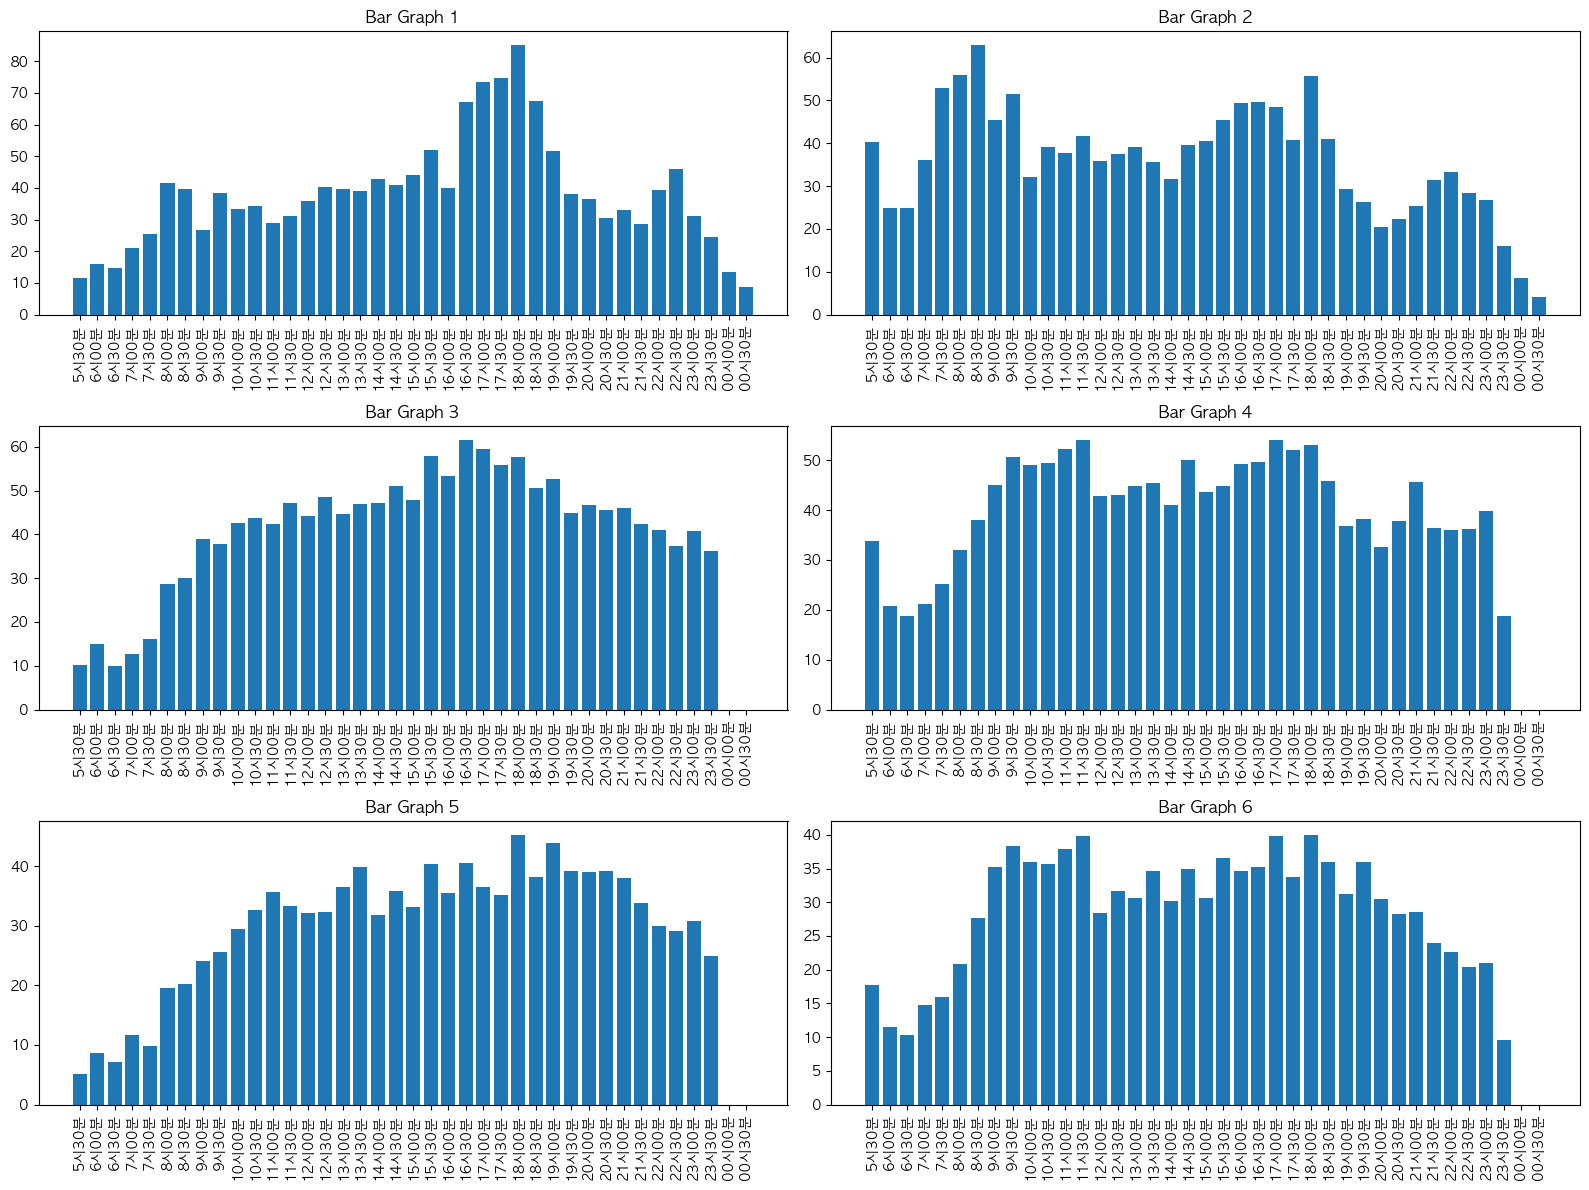

In [912]:
import matplotlib.pyplot as plt

# Create a figure with 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))  # 3 rows and 2 columns of subplots

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through the first 6 rows of `md` and create a bar graph for each
for i in range(6):
    axes[i].bar(
        x=md.iloc[:, 5:].columns, 
        height=md.iloc[i, 5:].values,
    )
    axes[i].set_title(f"Bar Graph {i+1}")
    axes[i].set_xticks(range(len(md.iloc[:, 5:].columns)))
    axes[i].set_xticklabels(md.iloc[:, 5:].columns, rotation=90)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

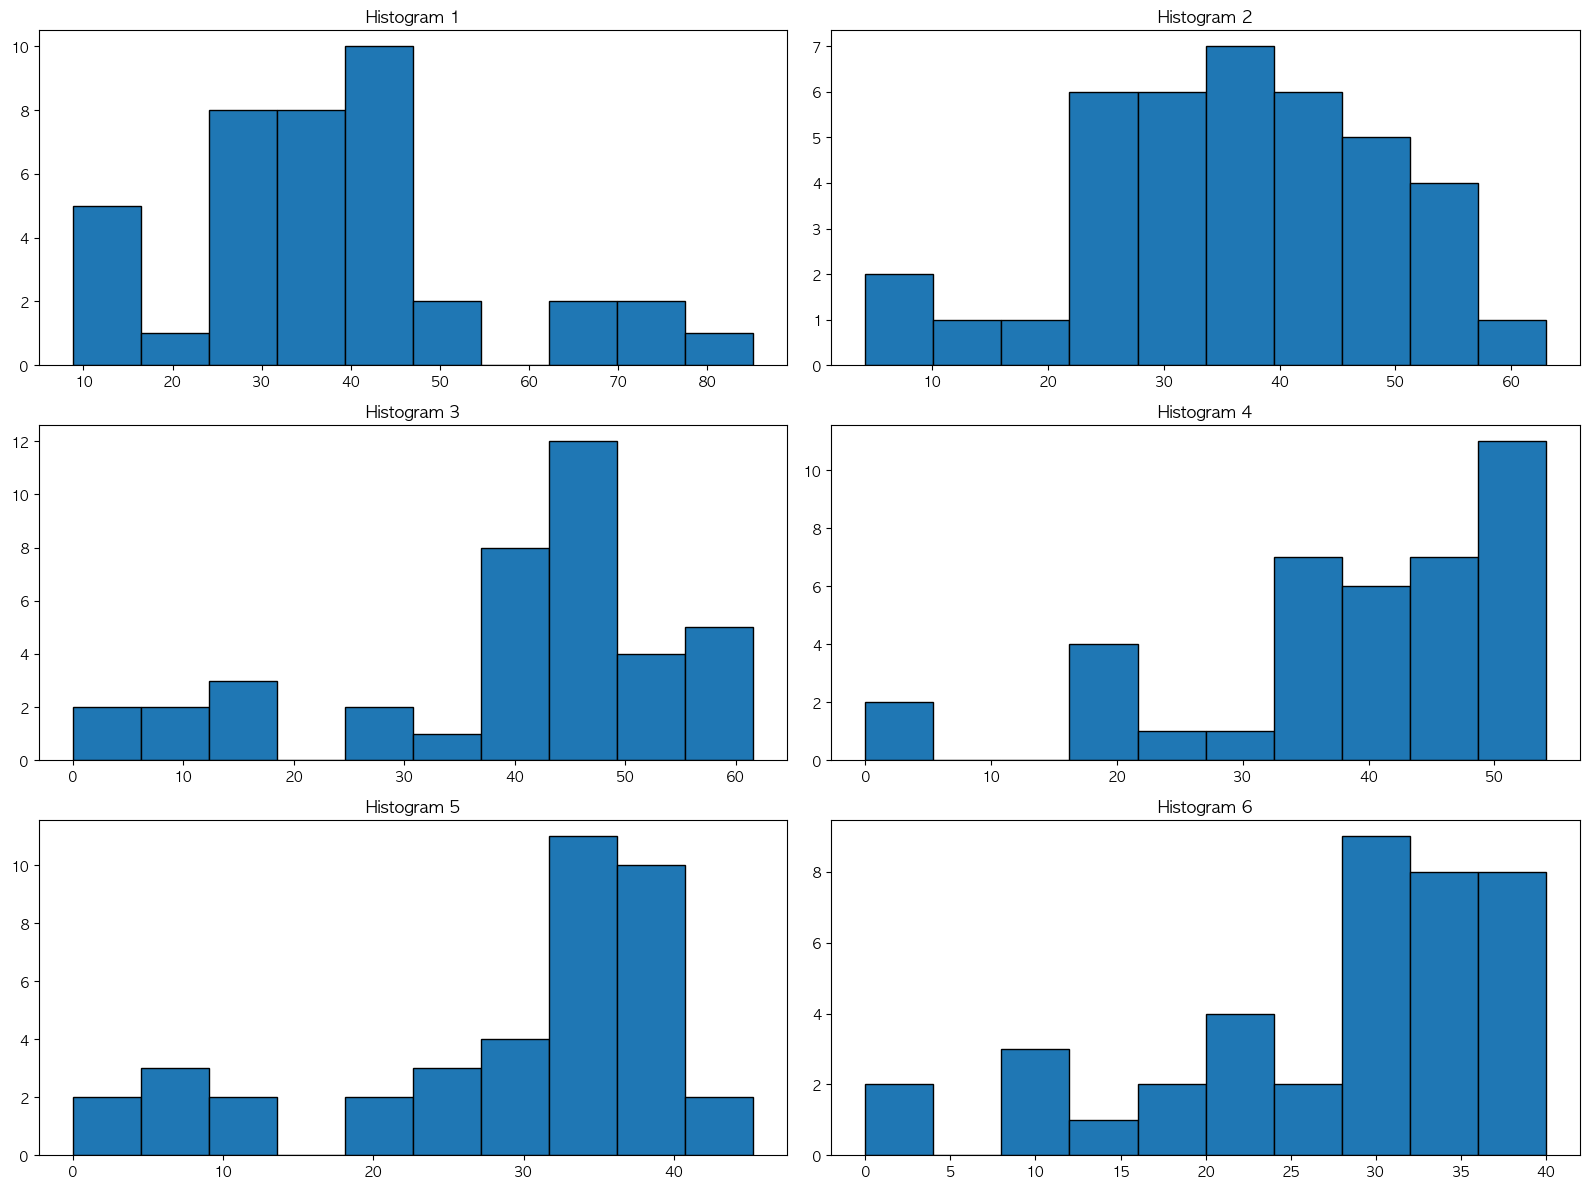

In [964]:
import matplotlib.pyplot as plt

# Create a figure with 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))  # 3 rows and 2 columns of subplots

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through the first 6 rows of `md` and create a histogram for each
for i in range(6):
    axes[i].hist(
        md.iloc[i, 5:].values, bins=10, edgecolor="black"  # Histogram data from the row
    )
    axes[i].set_title(f"Histogram {i+1}")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [921]:
md_up = md[md["상하구분"] == "상선"]
md_down = md[md["상하구분"] == "하선"]

In [806]:
md_up.drop(["역번호","출발역","상하구분","호선"],axis=1,inplace=True)


/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/2607264357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_up.drop(["역번호","출발역","상하구분","호선"],axis=1,inplace=True)


In [807]:
md_up = md_up.set_index("요일구분").T

In [808]:
md_up = md_up.rename_axis("시간", axis=1)

In [809]:
md_up

시간,평일,토요일,일요일
5시30분,11.4,10.1,5.1
6시00분,16.0,15.0,8.6
6시30분,14.8,9.9,7.1
7시00분,21.0,12.7,11.6
7시30분,25.3,16.0,9.8
8시00분,41.4,28.7,19.5
8시30분,39.6,30.0,20.2
9시00분,26.8,39.0,24.1
9시30분,38.5,37.9,25.7
10시00분,33.3,42.7,29.4


In [810]:
md_up.index = [i.replace("시","") for i in md_up.index]
md_up.index = [i.replace("분","").zfill(4) for i in md_up.index]

In [811]:
# md_up["시간"] = [ i.zfill(4) for i in md_up.index]

In [812]:
md_up.to_csv("../data/md_up.csv",index=False)

In [813]:
from glob import glob

In [814]:
station_files_2024_3 = glob("../Data/subway/*.csv")

In [815]:
station_files_2024_3

['../Data/subway/CARD_SUBWAY_MONTH_202409.csv',
 '../Data/subway/CARD_SUBWAY_MONTH_202408.csv',
 '../Data/subway/CARD_SUBWAY_MONTH_202407.csv']

In [816]:
tmp_raw = []
for file_name in station_files_2024_3:
    tmp = pd.read_csv(file_name, encoding='UTF-8')
    tmp_raw.append(tmp)

station_files_2023_2 = pd.concat(tmp_raw)

In [817]:
station_files_2023_2

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
20240901,2호선,한양대,3196,3787,20240904,NaN
20240901,2호선,왕십리(성동구청),9810,9629,20240904,NaN
20240901,2호선,상왕십리,7829,7960,20240904,NaN
20240901,2호선,신당,9347,9929,20240904,NaN
20240901,2호선,동대문역사문화공원(DDP),11351,13649,20240904,NaN
...,...,...,...,...,...,...
20240731,7호선,신풍,11494,10664,20240803,NaN
20240731,7호선,대림(구로구청),9328,9366,20240803,NaN
20240731,7호선,남구로,15284,16072,20240803,NaN
20240731,7호선,가산디지털단지,47493,47452,20240803,NaN


In [818]:
station_files_2023_md = station_files_2023_2[station_files_2023_2["노선명"] == "명동"]

In [592]:
station_files_2023_md

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
20240901,4호선,명동,29083,31642,20240904,NaN
20240902,4호선,명동,36489,38668,20240905,NaN
20240903,4호선,명동,37961,40350,20240906,NaN
20240904,4호선,명동,39217,41420,20240907,NaN
20240905,4호선,명동,38354,40774,20240908,NaN
...,...,...,...,...,...,...
20240727,4호선,명동,27401,31046,20240730,NaN
20240728,4호선,명동,27284,30267,20240731,NaN
20240729,4호선,명동,33905,36589,20240801,NaN
20240730,4호선,명동,33720,35726,20240802,NaN


In [585]:
station_files_2023_md= station_files_2023_md.drop(["등록일자","하차총승객수"],axis=1)
station_files_2023_md.drop(["사용일자","노선명"],axis=1,inplace=True)
station_files_2023_md.rename({"승차총승객수" : "하차총승객수"}, axis=1, inplace=True)
station_files_2023_md.rename({"역명" : "승차총승객수"}, axis=1,inplace=True)

In [541]:
station_files_2023_md = station_files_2023_md.sort_index(ascending=False)

In [542]:
station_files_2023_md 

,승차총승객수,하차총승객수
20240930,35114,37504
20240929,30053,32617
20240928,35516,40020
20240927,39380,41882
20240926,38155,40329
...,...,...
20240705,34859,37404
20240704,32886,35219
20240703,33266,35154
20240702,29466,31173


# 기본 비율

In [553]:
station_files_2023_md

,승차총승객수,하차총승객수,monthtime
20240930,35114,37504,2024093
20240929,30053,32617,2024092
20240928,35516,40020,2024092
20240927,39380,41882,2024092
20240926,38155,40329,2024092
...,...,...,...
20240705,34859,37404,2024070
20240704,32886,35219,2024070
20240703,33266,35154,2024070
20240702,29466,31173,2024070


In [593]:
station_files_2023_md_adjust = station_files_2023_md

In [594]:
station_files_2023_md_adjust["monthtime"] = [str(i)[0:6] for i in station_files_2023_md_adjust.index]

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/3030497004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_files_2023_md_adjust["monthtime"] = [str(i)[0:6] for i in station_files_2023_md_adjust.index]


In [595]:
station_files_2023_md_adjust.drop("하차총승객수",axis=1,inplace=True)

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/2555685359.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_files_2023_md_adjust.drop("하차총승객수",axis=1,inplace=True)


In [606]:
df2_md = df2[df2["지하철역"] == "명동"].reset_index(drop=True)

In [607]:
df2_md

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202411,4호선,명동,44,0,1892,1466,4132,25061,9020,...,9904,2282,3081,0,142,0,0,0,0,20241203
1,202410,4호선,명동,33,1,1978,1898,4503,25187,9685,...,9844,1912,2830,0,124,0,0,0,0,20241103
2,202409,4호선,명동,34,8,1757,1459,4100,21821,8848,...,10286,1801,2971,6,113,0,0,0,0,20241003
3,202408,4호선,명동,27,9,1743,1424,3943,23025,8263,...,10738,1906,3002,1,125,0,0,0,0,20240903
4,202407,4호선,명동,23,2,1529,1485,3836,24450,8515,...,10481,2035,2955,0,120,0,0,0,0,20240803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,201505,4호선,명동,24,0,1318,2034,3526,19737,6664,...,12059,2950,3003,0,110,0,0,0,0,20151223
115,201504,4호선,명동,37,0,1385,1990,3705,20809,7356,...,12114,3540,3253,1,121,0,0,0,0,20151223
116,201503,4호선,명동,13,0,1437,2214,3487,19518,7021,...,11463,3465,3137,0,99,1,0,0,0,20151223
117,201502,4호선,명동,16,0,1129,1735,2697,15968,5475,...,8913,3095,2359,30,87,0,3,0,0,20151223


In [608]:
df2_md_3 = df2_md.loc[2:4,:]

In [609]:
df2_md_3.drop(["호선명","지하철역"],axis=1,inplace= True)
df2_md_3.drop("작업일자",axis=1,inplace= True)

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/1648160603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_md_3.drop(["호선명","지하철역"],axis=1,inplace= True)
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/1648160603.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_md_3.drop("작업일자",axis=1,inplace= True)


In [610]:
df2_md_3 = df2_md_3.set_index("사용월").T

In [611]:
df2_md_3_up = df2_md_3[df2_md_3.index.str.contains("승차인원")]

In [612]:
df2_md_3_up.index = [str(int(str(i)[0:2]) * 100).zfill(4) for i in df2_md_3_up.index]

In [613]:
df2_md_3_up

사용월,202409,202408,202407
0400,34,27,23
0500,1757,1743,1529
0600,4100,3943,3836
0700,8848,8263,8515
0800,18235,16638,15704
0900,31778,32178,28792
1000,37295,39767,36226
1100,43447,44617,42392
1200,45331,44202,43145
1300,48868,47153,46514


In [614]:
sum_row = df2_md_3_up.iloc[:, 0:].sum()
sum_row = pd.DataFrame([sum_row], columns=df2_md_3_up.columns[0:])

In [615]:
sum_row

사용월,202409,202408,202407
0,1024371,1000846,988484


In [436]:
df2_md_3_up = pd.concat([df2_md_3_up, sum_row], ignore_index=True)

In [437]:
df2_md_3_up.rename({24:"합계"},axis=0,inplace=True)

In [438]:
df2_md_3_up.to_csv("../data/df2_md_3_up.csv",index=False)


In [519]:
df2_md_3_up_new = pd.read_csv("../data/df2_md_3_up.csv")

In [520]:
df2_md_3_up_new

,202409,202408,202407
0,34,27,23
1,1757,1743,1529
2,4100,3943,3836
3,8848,8263,8515
4,18235,16638,15704
5,31778,32178,28792
6,37295,39767,36226
7,43447,44617,42392
8,45331,44202,43145
9,48868,47153,46514


In [521]:
df2_md_3_up_new["202409R"] = (df2_md_3_up_new["202409"] / 1024371).round(5)
df2_md_3_up_new["202408R"] = (df2_md_3_up_new["202408"] / 1000846).round(5)
df2_md_3_up_new["202407R"] = (df2_md_3_up_new["202407"] / 988484).round(5)

In [577]:
(1024371 + 1000846 + 988484)/3


1004567.0

In [522]:
df2_md_3_up_new = df2_md_3_up_new[["202409"	,"202409R",	"202408",	"202408R",	"202407",	"202407R"]]

In [523]:
df2_md_3_up_new

,202409,202409R,202408,202408R,202407,202407R
0,34,0.00003,27,0.00003,23,0.00002
1,1757,0.00172,1743,0.00174,1529,0.00155
2,4100,0.00400,3943,0.00394,3836,0.00388
3,8848,0.00864,8263,0.00826,8515,0.00861
4,18235,0.01780,16638,0.01662,15704,0.01589
5,31778,0.03102,32178,0.03215,28792,0.02913
6,37295,0.03641,39767,0.03973,36226,0.03665
7,43447,0.04241,44617,0.04458,42392,0.04289
8,45331,0.04425,44202,0.04416,43145,0.04365
9,48868,0.04771,47153,0.04711,46514,0.04706


In [526]:
df2_md_3_up_new.drop(24,axis=0,inplace=True)

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/1988664497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_md_3_up_new.drop(24,axis=0,inplace=True)


In [527]:
df2_md_3_up_new["202409DT"] = [f"202409{i}" for i in df2_md_3_up.index]
df2_md_3_up_new["202408DT"] = [f"202408{i}" for i in df2_md_3_up.index]
df2_md_3_up_new["202407DT"] = [f"202407{i}" for i in df2_md_3_up.index]

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/705135699.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_md_3_up_new["202409DT"] = [f"202409{i}" for i in df2_md_3_up.index]
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/705135699.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_md_3_up_new["202408DT"] = [f"202408{i}" for i in df2_md_3_up.index]
/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/705135699.py:3: SettingWithCopyWarning: 
A value 

In [529]:
df2_md_3_up_new = df2_md_3_up_new[["202409"	,"202409R",	"202409DT",	"202408",	"202408R",	"202408DT","202407","202407R","202407DT"]]

In [530]:
df2_md_3_up_new

,202409,202409R,202409DT,202408,202408R,202408DT,202407,202407R,202407DT
0,34,0.00003,2024090400,27,0.00003,2024080400,23,0.00002,2024070400
1,1757,0.00172,2024090500,1743,0.00174,2024080500,1529,0.00155,2024070500
2,4100,0.00400,2024090600,3943,0.00394,2024080600,3836,0.00388,2024070600
3,8848,0.00864,2024090700,8263,0.00826,2024080700,8515,0.00861,2024070700
4,18235,0.01780,2024090800,16638,0.01662,2024080800,15704,0.01589,2024070800
5,31778,0.03102,2024090900,32178,0.03215,2024080900,28792,0.02913,2024070900
6,37295,0.03641,2024091000,39767,0.03973,2024081000,36226,0.03665,2024071000
7,43447,0.04241,2024091100,44617,0.04458,2024081100,42392,0.04289,2024071100
8,45331,0.04425,2024091200,44202,0.04416,2024081200,43145,0.04365,2024071200
9,48868,0.04771,2024091300,47153,0.04711,2024081300,46514,0.04706,2024071300


In [533]:
# Filter columns for original values, ratios, and datetime
value_cols = [col for col in df2_md_3_up_new.columns if not col.endswith("R") and not col.endswith("DT")]
ratio_cols = [col for col in df2_md_3_up_new.columns if col.endswith("R")]
datetime_cols = [col for col in df2_md_3_up_new.columns if col.endswith("DT")]

# Create a new DataFrame with the unified structure
restructured_df = pd.DataFrame()

# Iterate through the columns, combining values, ratios, and datetime
for value_col, ratio_col, datetime_col in zip(value_cols, ratio_cols, datetime_cols):
    temp_df = pd.DataFrame({
        "in": df2_md_3_up_new[value_col],
        "ratio": df2_md_3_up_new[ratio_col],
        "datetime": df2_md_3_up_new[datetime_col].astype(str)  # Keep as string format
    })
    restructured_df = pd.concat([restructured_df, temp_df], ignore_index=True)

# Sort by datetime column as a string (no conversion to datetime object needed)
restructured_df = restructured_df.sort_values(by="datetime").reset_index(drop=True)

# Display the result
print(restructured_df)

       in    ratio    datetime
0    2035  0.00206  2024070000
1       0  0.00000  2024070100
2       0  0.00000  2024070200
3       0  0.00000  2024070300
4      23  0.00002  2024070400
..    ...      ...         ...
67  83852  0.08186  2024091900
68  75322  0.07353  2024092000
69  75314  0.07352  2024092100
70  69832  0.06817  2024092200
71  28726  0.02804  2024092300

[72 rows x 3 columns]


In [534]:
restructured_df["monthtime"]

,in,ratio,datetime
0,2035,0.00206,2024070000
1,0,0.00000,2024070100
2,0,0.00000,2024070200
3,0,0.00000,2024070300
4,23,0.00002,2024070400
...,...,...,...
67,83852,0.08186,2024091900
68,75322,0.07353,2024092000
69,75314,0.07352,2024092100
70,69832,0.06817,2024092200


In [572]:
restructured_df

,in,ratio,datetime
0,2035,0.00206,2024070000
1,0,0.00000,2024070100
2,0,0.00000,2024070200
3,0,0.00000,2024070300
4,23,0.00002,2024070400
...,...,...,...
67,83852,0.08186,2024091900
68,75322,0.07353,2024092000
69,75314,0.07352,2024092100
70,69832,0.06817,2024092200


In [559]:
station_files_2023_md_adjust

,승차총승객수,monthtime
20240930,35114,202409
20240929,30053,202409
20240928,35516,202409
20240927,39380,202409
20240926,38155,202409
...,...,...
20240705,34859,202407
20240704,32886,202407
20240703,33266,202407
20240702,29466,202407


In [560]:
# Define the hours you want to add (from 00 to 23)
hours = [f"{hour:02}" for hour in range(24)]  # Generates ['00', '01', ..., '23']

# Create an empty DataFrame to store the expanded data
expanded_df = pd.DataFrame()

# Loop through each row in the original DataFrame
for _, row in station_files_2023_md_adjust.iterrows():
    # For each hour, create a new row with the hour appended to the date
    for hour in hours:
        new_row = {
            "yearmonthdatetime": f"{row.name}{hour}00",  # Add hour and minutes (HHMM)
            "승차총승객수": row["승차총승객수"],
            "monthtime": row["monthtime"]
        }
        expanded_df = pd.concat([expanded_df, pd.DataFrame([new_row])], ignore_index=True)

# Set the desired column order
expanded_df = expanded_df[["yearmonthdatetime", "승차총승객수", "monthtime"]]

# Display the expanded DataFrame
print(expanded_df)

     yearmonthdatetime  승차총승객수 monthtime
0         202409300000   35114    202409
1         202409300100   35114    202409
2         202409300200   35114    202409
3         202409300300   35114    202409
4         202409300400   35114    202409
...                ...     ...       ...
2203      202407011900   33431    202407
2204      202407012000   33431    202407
2205      202407012100   33431    202407
2206      202407012200   33431    202407
2207      202407012300   33431    202407

[2208 rows x 3 columns]


In [570]:
expanded_df["datetime"] = [str(i)[0:6] + str(i)[8:12] for i in expanded_df["yearmonthdatetime"]]

In [571]:
expanded_df
1004567

,yearmonthdatetime,승차총승객수,monthtime,datetime
0,202409300000,35114,202409,2024090000
1,202409300100,35114,202409,2024090100
2,202409300200,35114,202409,2024090200
3,202409300300,35114,202409,2024090300
4,202409300400,35114,202409,2024090400
...,...,...,...,...
2203,202407011900,33431,202407,2024071900
2204,202407012000,33431,202407,2024072000
2205,202407012100,33431,202407,2024072100
2206,202407012200,33431,202407,2024072200


In [573]:
merged_df = pd.merge(expanded_df, restructured_df, on="datetime", how="left")

In [574]:
merged_df

,yearmonthdatetime,승차총승객수,monthtime,datetime,in,ratio
0,202409300000,35114,202409,2024090000,1801,0.00176
1,202409300100,35114,202409,2024090100,6,0.00001
2,202409300200,35114,202409,2024090200,0,0.00000
3,202409300300,35114,202409,2024090300,0,0.00000
4,202409300400,35114,202409,2024090400,34,0.00003
...,...,...,...,...,...,...
2203,202407011900,33431,202407,2024071900,79890,0.08082
2204,202407012000,33431,202407,2024072000,73067,0.07392
2205,202407012100,33431,202407,2024072100,71583,0.07242
2206,202407012200,33431,202407,2024072200,67058,0.06784


In [575]:
merged_df["in"] = merged_df["승차총승객수"] * merged_df["ratio"]

In [576]:
merged_df

,yearmonthdatetime,승차총승객수,monthtime,datetime,in,ratio
0,202409300000,35114,202409,2024090000,61.80064,0.00176
1,202409300100,35114,202409,2024090100,0.35114,0.00001
2,202409300200,35114,202409,2024090200,0.00000,0.00000
3,202409300300,35114,202409,2024090300,0.00000,0.00000
4,202409300400,35114,202409,2024090400,1.05342,0.00003
...,...,...,...,...,...,...
2203,202407011900,33431,202407,2024071900,2701.89342,0.08082
2204,202407012000,33431,202407,2024072000,2471.21952,0.07392
2205,202407012100,33431,202407,2024072100,2421.07302,0.07242
2206,202407012200,33431,202407,2024072200,2267.95904,0.06784


In [616]:
np.average(merged_df["승차총승객수"])

32757.619565217392

In [617]:
32757

32757

In [766]:
# md_up = pd.read_csv("../data/md_up.csv")

In [819]:
md_up

시간,평일,토요일,일요일
0530,11.4,10.1,5.1
0600,16.0,15.0,8.6
0630,14.8,9.9,7.1
0700,21.0,12.7,11.6
0730,25.3,16.0,9.8
0800,41.4,28.7,19.5
0830,39.6,30.0,20.2
0900,26.8,39.0,24.1
0930,38.5,37.9,25.7
1000,33.3,42.7,29.4


In [820]:
md_up["시간"] = [ str(i).zfill(4) for i in md_up.index]

In [821]:
md_up

시간,평일,토요일,일요일,시간
0530,11.4,10.1,5.1,0530
0600,16.0,15.0,8.6,0600
0630,14.8,9.9,7.1,0630
0700,21.0,12.7,11.6,0700
0730,25.3,16.0,9.8,0730
0800,41.4,28.7,19.5,0800
0830,39.6,30.0,20.2,0830
0900,26.8,39.0,24.1,0900
0930,38.5,37.9,25.7,0930
1000,33.3,42.7,29.4,1000


In [822]:
md_up['시간_1시간'] = md_up['시간'].str[:2] + "00"

In [823]:
md_up

시간,평일,토요일,일요일,시간,시간_1시간
0530,11.4,10.1,5.1,0530,0500
0600,16.0,15.0,8.6,0600,0600
0630,14.8,9.9,7.1,0630,0600
0700,21.0,12.7,11.6,0700,0700
0730,25.3,16.0,9.8,0730,0700
0800,41.4,28.7,19.5,0800,0800
0830,39.6,30.0,20.2,0830,0800
0900,26.8,39.0,24.1,0900,0900
0930,38.5,37.9,25.7,0930,0900
1000,33.3,42.7,29.4,1000,1000


In [826]:
hourly_df = md_up.groupby('시간_1시간').sum(numeric_only=True) / 2

In [829]:
hourly_df = hourly_df.reset_index()

In [833]:
hourly_df["base"] = 32757

In [842]:
hourly_df.rename(columns={"시간_1시간": "time"}, inplace=True)

In [844]:
hourly_df["time"] = [ str(i)[0:2].zfill(2) for i in hourly_df["time"]]

In [845]:
hourly_df

시간,time,평일,토요일,일요일,base
0,00,11.05,0.00,0.00,32757
1,05,5.70,5.05,2.55,32757
2,06,15.40,12.45,7.85,32757
3,07,23.15,14.35,10.70,32757
4,08,40.50,29.35,19.85,32757
5,09,32.65,38.45,24.90,32757
6,10,33.85,43.25,31.00,32757
7,11,30.00,44.75,34.50,32757
8,12,38.10,46.35,32.25,32757
9,13,39.35,45.80,38.25,32757


In [849]:
merged_df["time"] = [ str(i)[8:10] for i in merged_df["yearmonthdatetime"]]

In [851]:
final_md = pd.merge(merged_df, hourly_df, on="time", how="left")

In [854]:
final_md.to_csv("../data/final_md.csv")

In [855]:
final_md.dropna(axis=0,how="any",inplace=True)

In [856]:
final_md

,yearmonthdatetime,승차총승객수,monthtime,datetime,in,ratio,time,평일,토요일,일요일,base
0,202409300000,35114,202409,2024090000,61.80064,0.00176,00,11.05,0.00,0.00,32757.0
5,202409300500,35114,202409,2024090500,60.39608,0.00172,05,5.70,5.05,2.55,32757.0
6,202409300600,35114,202409,2024090600,140.45600,0.00400,06,15.40,12.45,7.85,32757.0
7,202409300700,35114,202409,2024090700,303.38496,0.00864,07,23.15,14.35,10.70,32757.0
8,202409300800,35114,202409,2024090800,625.02920,0.01780,08,40.50,29.35,19.85,32757.0
...,...,...,...,...,...,...,...,...,...,...,...
2203,202407011900,33431,202407,2024071900,2701.89342,0.08082,19,44.85,48.80,41.60,32757.0
2204,202407012000,33431,202407,2024072000,2471.21952,0.07392,20,33.50,46.10,39.15,32757.0
2205,202407012100,33431,202407,2024072100,2421.07302,0.07242,21,30.75,44.20,35.95,32757.0
2206,202407012200,33431,202407,2024072200,2267.95904,0.06784,22,42.75,39.20,29.60,32757.0


In [875]:
final_md["target_WD"] = [round((i * j) / 32757.0, 2) for i, j in zip(final_md["평일"], final_md["승차총승객수"])]
final_md["target_Sat"] = [round((i * j) / 32757.0, 2) for i, j in zip(final_md["토요일"], final_md["승차총승객수"])]
final_md["target_Sun"] = [round((i * j) / 32757.0, 2) for i, j in zip(final_md["일요일"], final_md["승차총승객수"])]

In [876]:
final_md

,yearmonthdatetime,승차총승객수,monthtime,datetime,in,ratio,time,평일,토요일,일요일,base,target_WD,target_Sat,target_Sun
0,202409300000,35114,202409,2024090000,61.80064,0.00176,00,11.05,0.00,0.00,32757.0,11.85,0.00,0.00
5,202409300500,35114,202409,2024090500,60.39608,0.00172,05,5.70,5.05,2.55,32757.0,6.11,5.41,2.73
6,202409300600,35114,202409,2024090600,140.45600,0.00400,06,15.40,12.45,7.85,32757.0,16.51,13.35,8.41
7,202409300700,35114,202409,2024090700,303.38496,0.00864,07,23.15,14.35,10.70,32757.0,24.82,15.38,11.47
8,202409300800,35114,202409,2024090800,625.02920,0.01780,08,40.50,29.35,19.85,32757.0,43.41,31.46,21.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2203,202407011900,33431,202407,2024071900,2701.89342,0.08082,19,44.85,48.80,41.60,32757.0,45.77,49.80,42.46
2204,202407012000,33431,202407,2024072000,2471.21952,0.07392,20,33.50,46.10,39.15,32757.0,34.19,47.05,39.96
2205,202407012100,33431,202407,2024072100,2421.07302,0.07242,21,30.75,44.20,35.95,32757.0,31.38,45.11,36.69
2206,202407012200,33431,202407,2024072200,2267.95904,0.06784,22,42.75,39.20,29.60,32757.0,43.63,40.01,30.21


In [877]:
final_md["monthday"] = [ i[0:8] for i in final_md["yearmonthdatetime"]]

In [878]:
final_md

,yearmonthdatetime,승차총승객수,monthtime,datetime,in,ratio,time,평일,토요일,일요일,base,target_WD,target_Sat,target_Sun,monthday
0,202409300000,35114,202409,2024090000,61.80064,0.00176,00,11.05,0.00,0.00,32757.0,11.85,0.00,0.00,20240930
5,202409300500,35114,202409,2024090500,60.39608,0.00172,05,5.70,5.05,2.55,32757.0,6.11,5.41,2.73,20240930
6,202409300600,35114,202409,2024090600,140.45600,0.00400,06,15.40,12.45,7.85,32757.0,16.51,13.35,8.41,20240930
7,202409300700,35114,202409,2024090700,303.38496,0.00864,07,23.15,14.35,10.70,32757.0,24.82,15.38,11.47,20240930
8,202409300800,35114,202409,2024090800,625.02920,0.01780,08,40.50,29.35,19.85,32757.0,43.41,31.46,21.28,20240930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2203,202407011900,33431,202407,2024071900,2701.89342,0.08082,19,44.85,48.80,41.60,32757.0,45.77,49.80,42.46,20240701
2204,202407012000,33431,202407,2024072000,2471.21952,0.07392,20,33.50,46.10,39.15,32757.0,34.19,47.05,39.96,20240701
2205,202407012100,33431,202407,2024072100,2421.07302,0.07242,21,30.75,44.20,35.95,32757.0,31.38,45.11,36.69,20240701
2206,202407012200,33431,202407,2024072200,2267.95904,0.06784,22,42.75,39.20,29.60,32757.0,43.63,40.01,30.21,20240701


In [879]:
monthday_3rd_2024 = pd.read_csv("../data/monthday_3rd_2024.csv")

In [880]:
monthday_3rd_2024

,monthday,weekday_sat_sun
0,20240701,0
1,20240702,0
2,20240703,0
3,20240704,0
4,20240705,0
...,...,...
87,20240926,0
88,20240927,0
89,20240928,1
90,20240929,2


In [885]:
final_md["monthday"] = final_md["monthday"].astype(str)
monthday_3rd_2024["monthday"] = monthday_3rd_2024["monthday"].astype(str)

In [886]:
final_md = pd.merge(final_md, monthday_3rd_2024, on="monthday", how="left")

In [887]:
final_md

,yearmonthdatetime,승차총승객수,monthtime,datetime,in,ratio,time,평일,토요일,일요일,base,target_WD,target_Sat,target_Sun,monthday,weekday_sat_sun
0,202409300000,35114,202409,2024090000,61.80064,0.00176,00,11.05,0.00,0.00,32757.0,11.85,0.00,0.00,20240930,0
1,202409300500,35114,202409,2024090500,60.39608,0.00172,05,5.70,5.05,2.55,32757.0,6.11,5.41,2.73,20240930,0
2,202409300600,35114,202409,2024090600,140.45600,0.00400,06,15.40,12.45,7.85,32757.0,16.51,13.35,8.41,20240930,0
3,202409300700,35114,202409,2024090700,303.38496,0.00864,07,23.15,14.35,10.70,32757.0,24.82,15.38,11.47,20240930,0
4,202409300800,35114,202409,2024090800,625.02920,0.01780,08,40.50,29.35,19.85,32757.0,43.41,31.46,21.28,20240930,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835,202407011900,33431,202407,2024071900,2701.89342,0.08082,19,44.85,48.80,41.60,32757.0,45.77,49.80,42.46,20240701,0
1836,202407012000,33431,202407,2024072000,2471.21952,0.07392,20,33.50,46.10,39.15,32757.0,34.19,47.05,39.96,20240701,0
1837,202407012100,33431,202407,2024072100,2421.07302,0.07242,21,30.75,44.20,35.95,32757.0,31.38,45.11,36.69,20240701,0
1838,202407012200,33431,202407,2024072200,2267.95904,0.06784,22,42.75,39.20,29.60,32757.0,43.63,40.01,30.21,20240701,0


In [940]:
final_md

,yearmonthdatetime,승차총승객수,monthtime,datetime,in,ratio,time,평일,토요일,일요일,base,target_WD,target_Sat,target_Sun,monthday,weekday_sat_sun
0,202409300000,35114,202409,2024090000,61.80064,0.00176,00,11.05,0.00,0.00,32757.0,11.85,0.00,0.00,20240930,0
1,202409300500,35114,202409,2024090500,60.39608,0.00172,05,5.70,5.05,2.55,32757.0,6.11,5.41,2.73,20240930,0
2,202409300600,35114,202409,2024090600,140.45600,0.00400,06,15.40,12.45,7.85,32757.0,16.51,13.35,8.41,20240930,0
3,202409300700,35114,202409,2024090700,303.38496,0.00864,07,23.15,14.35,10.70,32757.0,24.82,15.38,11.47,20240930,0
4,202409300800,35114,202409,2024090800,625.02920,0.01780,08,40.50,29.35,19.85,32757.0,43.41,31.46,21.28,20240930,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835,202407011900,33431,202407,2024071900,2701.89342,0.08082,19,44.85,48.80,41.60,32757.0,45.77,49.80,42.46,20240701,0
1836,202407012000,33431,202407,2024072000,2471.21952,0.07392,20,33.50,46.10,39.15,32757.0,34.19,47.05,39.96,20240701,0
1837,202407012100,33431,202407,2024072100,2421.07302,0.07242,21,30.75,44.20,35.95,32757.0,31.38,45.11,36.69,20240701,0
1838,202407012200,33431,202407,2024072200,2267.95904,0.06784,22,42.75,39.20,29.60,32757.0,43.63,40.01,30.21,20240701,0


In [941]:
final_md_adjust = final_md[["target_WD","target_Sat","target_Sun","datetime","weekday_sat_sun","yearmonthdatetime"]]

# weather

In [891]:
final_md_adjust

,target_WD,target_Sat,target_Sun,datetime,weekday_sat_sun
0,11.85,0.00,0.00,2024090000,0
1,6.11,5.41,2.73,2024090500,0
2,16.51,13.35,8.41,2024090600,0
3,24.82,15.38,11.47,2024090700,0
4,43.41,31.46,21.28,2024090800,0
...,...,...,...,...,...
1835,45.77,49.80,42.46,2024071900,0
1836,34.19,47.05,39.96,2024072000,0
1837,31.38,45.11,36.69,2024072100,0
1838,43.63,40.01,30.21,2024072200,0


In [892]:
final_md_adjust["target_WD"] 

0       11.85
1        6.11
2       16.51
3       24.82
4       43.41
        ...  
1835    45.77
1836    34.19
1837    31.38
1838    43.63
1839    28.42
Name: target_WD, Length: 1840, dtype: float64

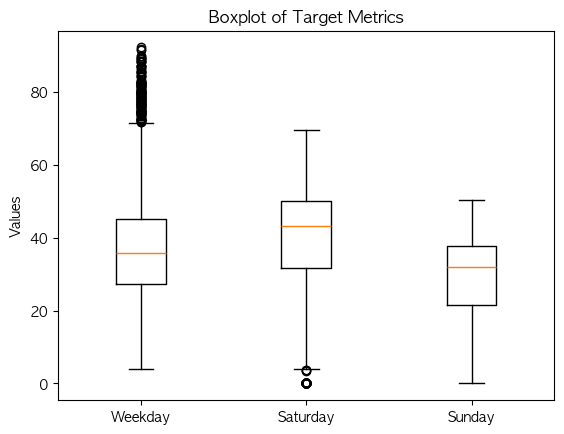

In [898]:
import matplotlib.pyplot as plt

# Create a list of datasets
data = [
    final_md_adjust["target_WD"],
    final_md_adjust["target_Sat"],
    final_md_adjust["target_Sun"]
]

# Plot the boxplot
plt.boxplot(data, labels=["Weekday", "Saturday", "Sunday"])

# Add a title and labels
plt.title("Boxplot of Target Metrics")
plt.ylabel("Values")

# Show the plot
plt.show()

In [942]:
weather = pd.read_csv('../Data/weather.csv')
weather['적설(cm)'] = weather['적설(cm)'].fillna(0)
weather['강수량(mm)'] = weather['강수량(mm)'].fillna(0)
weather['풍속(m/s)'] = weather['강수량(mm)'].fillna(0)
weather.drop('일사(MJ/m2)',axis=1,inplace=True)
weather.drop('Unnamed: 0',axis=1,inplace=True)
weather.drop('지점',axis=1,inplace=True)
weather.drop('지점명',axis=1,inplace=True)
weather_adj =  weather.copy()
weather_adj['기준_날짜'] =[ i.replace("-","")[0:8] for i in weather_adj['일시']]
weather_adj['month'] = [i[0:6] for i in weather_adj['기준_날짜']]
weather_adj['기준_시간대'] = [i[11:13].zfill(2) for i in weather_adj['일시']]
weather_adj['yearmonthdatetime'] = (
    weather_adj['기준_날짜'].astype(str) + 
    weather_adj['기준_시간대'].astype(str).str.zfill(2) + 
    "00"
)

In [949]:
weather_adj

,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),적설(cm),중하층운량(10분위),시정(10m),기준_날짜,month,기준_시간대,yearmonthdatetime
0,2023-10-01 00:00,17.1,0.0,0.0,69,13.4,11.3,1000.8,0.0,0,2000,20231001,202310,00,202310010000
1,2023-10-01 01:00,16.5,0.0,0.0,74,13.8,11.8,1001.1,0.0,0,2000,20231001,202310,01,202310010100
2,2023-10-01 02:00,15.9,0.0,0.0,78,14.0,12.0,1001.2,0.0,0,2000,20231001,202310,02,202310010200
3,2023-10-01 03:00,15.6,0.0,0.0,81,14.3,12.3,1001.2,0.0,0,2000,20231001,202310,03,202310010300
4,2023-10-01 04:00,15.4,0.0,0.0,82,14.3,12.3,1001.3,0.0,0,2000,20231001,202310,04,202310010400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9523,2024-10-31 19:00,17.2,0.0,0.0,60,11.7,9.3,1011.1,0.0,0,1995,20241031,202410,19,202410311900
9524,2024-10-31 20:00,16.6,0.0,0.0,63,11.9,9.5,1011.6,0.0,0,1429,20241031,202410,20,202410312000
9525,2024-10-31 21:00,15.8,0.0,0.0,67,11.9,9.6,1011.7,0.0,0,1328,20241031,202410,21,202410312100
9526,2024-10-31 22:00,14.9,0.0,0.0,71,11.9,9.6,1011.9,0.0,0,1307,20241031,202410,22,202410312200


In [950]:
final_md_adjust

,target_WD,target_Sat,target_Sun,datetime,weekday_sat_sun,yearmonthdatetime
0,11.85,0.00,0.00,2024090000,0,202409300000
1,6.11,5.41,2.73,2024090500,0,202409300500
2,16.51,13.35,8.41,2024090600,0,202409300600
3,24.82,15.38,11.47,2024090700,0,202409300700
4,43.41,31.46,21.28,2024090800,0,202409300800
...,...,...,...,...,...,...
1835,45.77,49.80,42.46,2024071900,0,202407011900
1836,34.19,47.05,39.96,2024072000,0,202407012000
1837,31.38,45.11,36.69,2024072100,0,202407012100
1838,43.63,40.01,30.21,2024072200,0,202407012200


In [952]:
weather_adj[weather_adj['yearmonthdatetime'] == 202310010000]

,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),적설(cm),중하층운량(10분위),시정(10m),기준_날짜,month,기준_시간대,yearmonthdatetime


In [953]:
weather_adj['yearmonthdatetime'] = weather_adj['yearmonthdatetime'].astype(str) 
final_md_adjust['yearmonthdatetime'] = final_md_adjust['yearmonthdatetime'].astype(str) 
final_md_weather = pd.merge(final_md_adjust, weather_adj, on="yearmonthdatetime", how="left")

/var/folders/hy/c34mqxh123lgnfptrbk38tjw0000gn/T/ipykernel_66005/468267413.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_md_adjust['yearmonthdatetime'] = final_md_adjust['yearmonthdatetime'].astype(str)


In [944]:
weather_adj

2024072300

In [954]:
final_md_weather

,target_WD,target_Sat,target_Sun,datetime,weekday_sat_sun,yearmonthdatetime,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),적설(cm),중하층운량(10분위),시정(10m),기준_날짜,month,기준_시간대
0,11.85,0.00,0.00,2024090000,0,202409300000,2024-09-30 00:00,21.6,0.0,0.0,68,17.5,15.4,1008.6,0.0,0,4738,20240930,202409,00
1,6.11,5.41,2.73,2024090500,0,202409300500,2024-09-30 05:00,18.9,0.0,0.0,75,16.3,14.3,1008.0,0.0,0,4487,20240930,202409,05
2,16.51,13.35,8.41,2024090600,0,202409300600,2024-09-30 06:00,18.5,0.0,0.0,75,15.9,13.9,1007.9,0.0,0,4017,20240930,202409,06
3,24.82,15.38,11.47,2024090700,0,202409300700,2024-09-30 07:00,18.5,0.0,0.0,75,15.9,13.9,1007.9,0.0,0,4185,20240930,202409,07
4,43.41,31.46,21.28,2024090800,0,202409300800,2024-09-30 08:00,19.8,0.0,0.0,70,16.1,14.1,1007.7,0.0,0,5000,20240930,202409,08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835,45.77,49.80,42.46,2024071900,0,202407011900,2024-07-01 19:00,29.5,0.0,0.0,61,25.0,21.1,993.4,0.0,3,2791,20240701,202407,19
1836,34.19,47.05,39.96,2024072000,0,202407012000,2024-07-01 20:00,27.8,0.0,0.0,67,25.0,21.1,994.0,0.0,4,2386,20240701,202407,20
1837,31.38,45.11,36.69,2024072100,0,202407012100,2024-07-01 21:00,26.5,0.0,0.0,71,24.6,20.8,995.0,0.0,0,2646,20240701,202407,21
1838,43.63,40.01,30.21,2024072200,0,202407012200,2024-07-01 22:00,25.9,0.0,0.0,74,24.7,20.9,995.4,0.0,3,2588,20240701,202407,22


In [962]:
final_md_weather_corr = final_md_weather[["target_WD",	"target_Sat",	"target_Sun",	"기온(°C)",	"강수량(mm)",	"풍속(m/s)",	"습도(%)",	"증기압(hPa)",	"이슬점온도(°C)",	"현지기압(hPa)",	"중하층운량(10분위)",	"시정(10m)","weekday_sat_sun"]]

In [963]:
final_md_weather_corr.corr()

,target_WD,target_Sat,target_Sun,기온(°C),강수량(mm),풍속(m/s),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),중하층운량(10분위),시정(10m),weekday_sat_sun
target_WD,1.000000,0.830365,0.767559,0.346798,-0.034031,-0.034031,-0.430120,-0.039117,-0.039767,-0.076231,-0.025701,0.140771,-0.137146
target_Sat,0.830365,1.000000,0.971691,0.401760,-0.036668,-0.036668,-0.492958,-0.033924,-0.033822,-0.052458,-0.030138,0.167146,-0.145663
target_Sun,0.767559,0.971691,1.000000,0.381060,-0.038220,-0.038220,-0.472755,-0.032975,-0.032510,-0.049774,-0.059032,0.174447,-0.140960
기온(°C),0.346798,0.401760,0.381060,1.000000,-0.141811,-0.141811,-0.499201,0.594121,0.596614,-0.236876,-0.097025,-0.078874,0.023717
강수량(mm),-0.034031,-0.036668,-0.038220,-0.141811,1.000000,1.000000,0.264565,0.070920,0.069141,-0.086022,0.206201,-0.221527,-0.047653
풍속(m/s),-0.034031,-0.036668,-0.038220,-0.141811,1.000000,1.000000,0.264565,0.070920,0.069141,-0.086022,0.206201,-0.221527,-0.047653
습도(%),-0.430120,-0.492958,-0.472755,-0.499201,0.264565,0.264565,1.000000,0.388371,0.392422,-0.225795,0.396585,-0.447485,-0.110649
증기압(hPa),-0.039117,-0.033924,-0.032975,0.594121,0.070920,0.070920,0.388371,1.000000,0.994497,-0.417311,0.243771,-0.455419,-0.074712
이슬점온도(°C),-0.039767,-0.033822,-0.032510,0.596614,0.069141,0.069141,0.392422,0.994497,1.000000,-0.446787,0.249433,-0.479532,-0.073947
현지기압(hPa),-0.076231,-0.052458,-0.049774,-0.236876,-0.086022,-0.086022,-0.225795,-0.417311,-0.446787,1.000000,-0.202046,0.414278,0.101915


In [968]:
final_md_weather_corr_WD = final_md_weather[["target_WD",	"기온(°C)",	"강수량(mm)",	"풍속(m/s)",	"습도(%)",	"증기압(hPa)",	"이슬점온도(°C)",	"현지기압(hPa)",	"중하층운량(10분위)",	"시정(10m)","weekday_sat_sun"]]
final_md_weather_corr_Sat = final_md_weather[["target_Sat", "기온(°C)",	"강수량(mm)",	"풍속(m/s)",	"습도(%)",	"증기압(hPa)",	"이슬점온도(°C)",	"현지기압(hPa)",	"중하층운량(10분위)",	"시정(10m)","weekday_sat_sun"]]
final_md_weather_corr_Sun = final_md_weather[["target_Sun",	"기온(°C)",	"강수량(mm)",	"풍속(m/s)",	"습도(%)",	"증기압(hPa)",	"이슬점온도(°C)",	"현지기압(hPa)",	"중하층운량(10분위)",	"시정(10m)","weekday_sat_sun"]]

In [969]:
final_md_weather_corr_Sat = final_md_weather_corr_Sat[final_md_weather_corr_Sat["target_Sat"] != 0]
final_md_weather_corr_Sun = final_md_weather_corr_Sun[final_md_weather_corr_Sun["target_Sun"] != 0]

KeyError: 'target_sun'

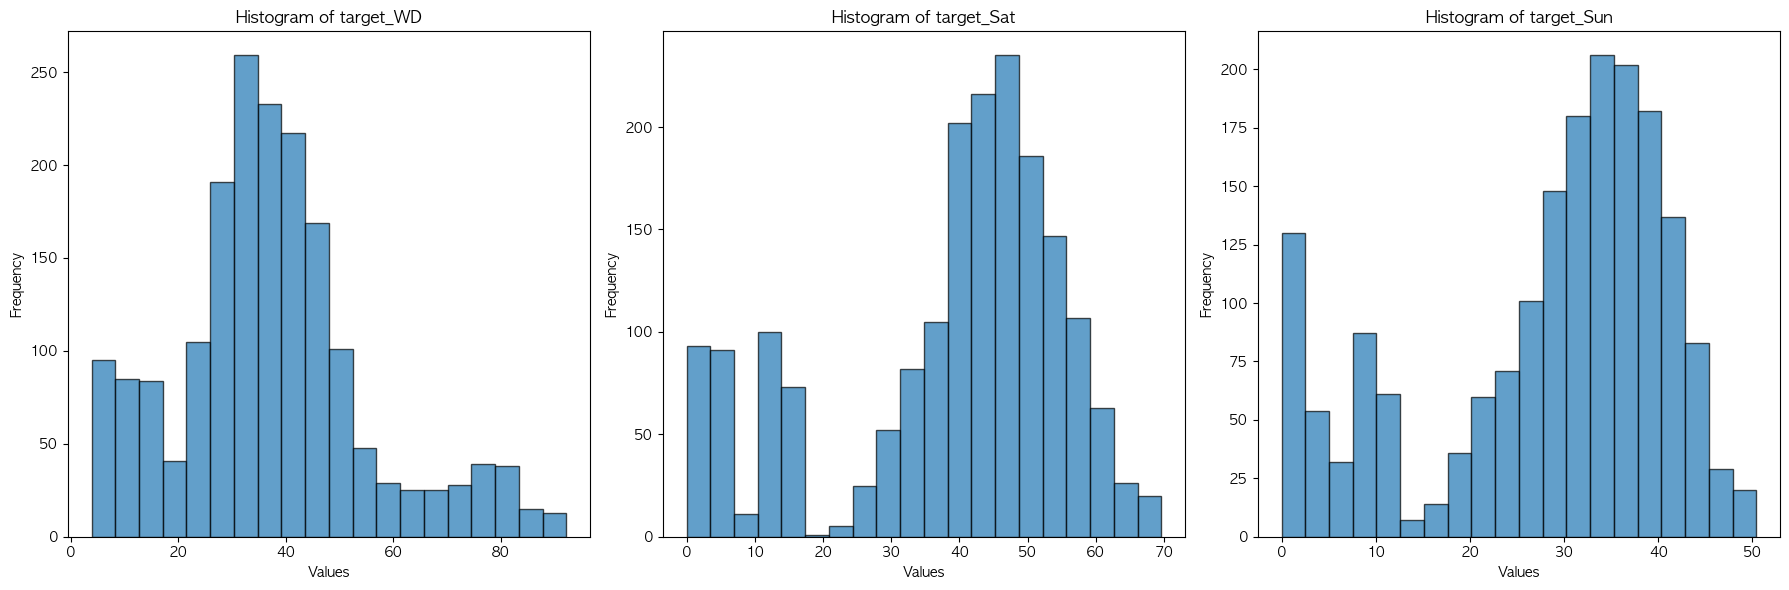

In [966]:
import matplotlib.pyplot as plt

# List of column names to plot
columns = ["target_WD", "target_Sat", "target_Sun"]

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns of subplots

# Loop through each column and draw the histogram
for i, col in enumerate(columns):
    axes[i].hist(final_md_weather_corr[col], bins=20, edgecolor="black", alpha=0.7)
    axes[i].set_title(f"Histogram of {col}")
    axes[i].set_xlabel("Values")
    axes[i].set_ylabel("Frequency")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [965]:
final_md_weather_corr["target_WD"]
final_md_weather_corr["target_Sat"]
final_md_weather_corr["target_Sun"]

0       11.85
1        6.11
2       16.51
3       24.82
4       43.41
        ...  
1835    45.77
1836    34.19
1837    31.38
1838    43.63
1839    28.42
Name: target_WD, Length: 1840, dtype: float64

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))  # 3 rows and 2 columns of subplots

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through the first 6 rows of `md` and create a histogram for each
for i in range(6):
    axes[i].hist(
        md.iloc[i, 5:].values, bins=10, edgecolor="black"  # Histogram data from the row
    )
    axes[i].set_title(f"Histogram {i+1}")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()